# Phase 2: Exploratory Data Analysis

This notebook explores the processed NOAA OISST California SST data and NOAA ONI data.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

SST_PATH = PROCESSED_DIR / "california_daily_sst_1982_2024.csv"
ONI_PATH = PROCESSED_DIR / "oni_monthly.csv"

print("SST path:", SST_PATH)
print("ONI path:", ONI_PATH)


SST path: /Users/sumi/Desktop/project/data/processed/california_daily_sst_1982_2024.csv
ONI path: /Users/sumi/Desktop/project/data/processed/oni_monthly.csv


In [3]:
sst = pd.read_csv(SST_PATH)
oni = pd.read_csv(ONI_PATH)

sst["date"] = pd.to_datetime(sst["date"])
oni["date"] = pd.to_datetime(oni["date"])

sst.head()


,date,year,sst
0,1982-01-01,1982,14.619334
1,1982-01-02,1982,14.521364
2,1982-01-03,1982,14.399932
3,1982-01-04,1982,14.327671
4,1982-01-05,1982,14.418211


In [4]:
oni.head()

,date,year,month,season,nino34_sst,oni,enso_phase
0,1950-01-01,1950,1,DJF,24.72,-1.53,La Niña
1,1950-02-01,1950,2,JFM,25.17,-1.34,La Niña
2,1950-03-01,1950,3,FMA,25.75,-1.16,La Niña
3,1950-04-01,1950,4,MAM,26.12,-1.18,La Niña
4,1950-05-01,1950,5,AMJ,26.32,-1.07,La Niña


In [5]:
# 基础数据检查

print("SST shape:", sst.shape)
print("ONI shape:", oni.shape)

print("\nSST info:")
print(sst.info())

print("\nSST missing values:")
print(sst.isna().sum())

print("\nONI missing values:")
print(oni.isna().sum())

SST shape: (15706, 3)
ONI shape: (917, 7)

SST info:
<class 'pandas.DataFrame'>
RangeIndex: 15706 entries, 0 to 15705
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    15706 non-null  datetime64[us]
 1   year    15706 non-null  int64         
 2   sst     15706 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 368.2 KB
None

SST missing values:
date    0
year    0
sst     0
dtype: int64

ONI missing values:
date          0
year          0
month         0
season        0
nino34_sst    0
oni           0
enso_phase    0
dtype: int64


In [6]:
sst.describe()

,date,year,sst
count,15706,15706.000000,15706.000000
mean,2003-07-02 12:00:00,2003.000700,15.813710
min,1982-01-01 00:00:00,1982.000000,12.321995
25%,1992-10-01 06:00:00,1992.000000,14.468449
50%,2003-07-02 12:00:00,2003.000000,15.577689
75%,2014-04-01 18:00:00,2014.000000,17.161776
max,2024-12-31 00:00:00,2024.000000,20.819645
std,NaN,12.410266,1.651474


In [7]:
# 检车年份范围

print("SST date range:")
print(sst["date"].min(), "to", sst["date"].max())

print("\nYears in SST data:")
print(sst["year"].unique())

print("\nNumber of days per year:")
sst.groupby("year")["date"].count()


SST date range:
1982-01-01 00:00:00 to 2024-12-31 00:00:00

Years in SST data:
[1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995
 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009
 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]

Number of days per year:


year
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    365
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    365
1999    365
2000    366
2001    365
2002    365
2003    365
2004    366
2005    365
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
Name: date, dtype: int64

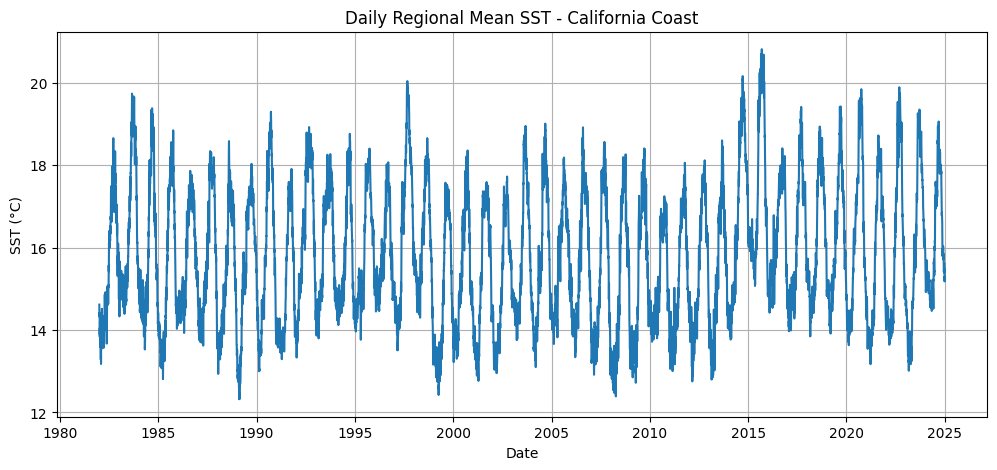

In [8]:
# 绘制日度 SST 时间序列

plt.figure(figsize=(12, 5))
plt.plot(sst["date"], sst["sst"])
plt.title("Daily Regional Mean SST - California Coast")
plt.xlabel("Date")
plt.ylabel("SST (°C)")
plt.grid(True)
plt.show()


In [9]:
# 月度平均 SST

sst["month"] = sst["date"].dt.month

monthly_sst = sst.groupby("month", as_index=False)["sst"].mean()

monthly_sst


,month,sst
0,1,14.360900
1,2,14.135258
2,3,14.142768
3,4,14.348306
4,5,14.871889
5,6,15.659915
6,7,16.883524
7,8,17.818973
8,9,18.126454
9,10,17.633014


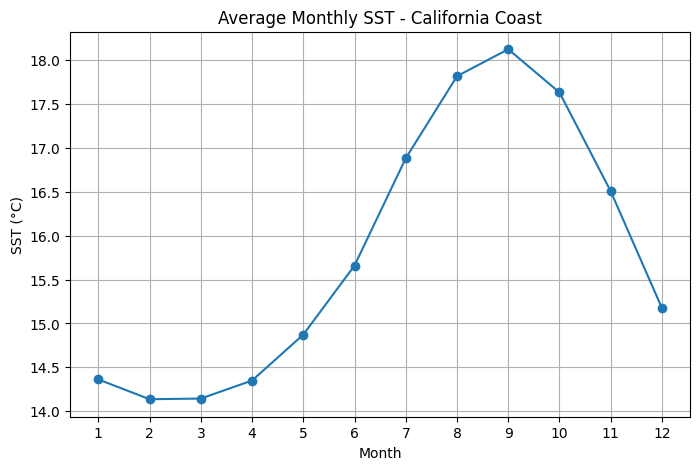

In [10]:
# 绘制季节性变化

plt.figure(figsize=(8, 5))
plt.plot(monthly_sst["month"], monthly_sst["sst"], marker="o")
plt.title("Average Monthly SST - California Coast")
plt.xlabel("Month")
plt.ylabel("SST (°C)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()


In [11]:
# 年度平均 SST

annual_sst = sst.groupby("year", as_index=False)["sst"].mean()

annual_sst


,year,sst
0,1982,15.590849
1,1983,16.490562
2,1984,15.914616
3,1985,15.439454
4,1986,15.841841
5,1987,15.766048
6,1988,15.371561
7,1989,15.540380
8,1990,15.884712
9,1991,15.078474


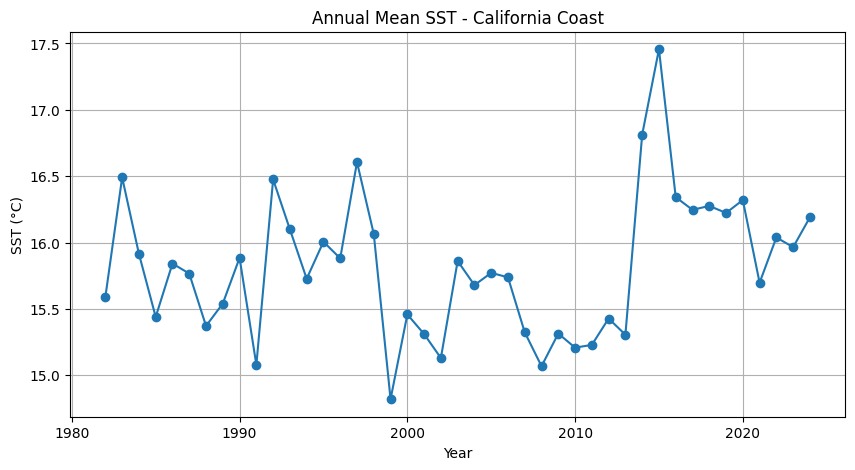

In [12]:
# 年度 SST 趋势

plt.figure(figsize=(10, 5))
plt.plot(annual_sst["year"], annual_sst["sst"], marker="o")
plt.title("Annual Mean SST - California Coast")
plt.xlabel("Year")
plt.ylabel("SST (°C)")
plt.grid(True)
plt.show()


In [13]:
# 计算简单线性趋势

x = annual_sst["year"].values
y = annual_sst["sst"].values

slope, intercept = np.polyfit(x, y, 1)

print(f"Estimated trend: {slope:.4f} °C per year")
print(f"Estimated trend: {slope * 10:.4f} °C per decade")


Estimated trend: 0.0085 °C per year
Estimated trend: 0.0849 °C per decade


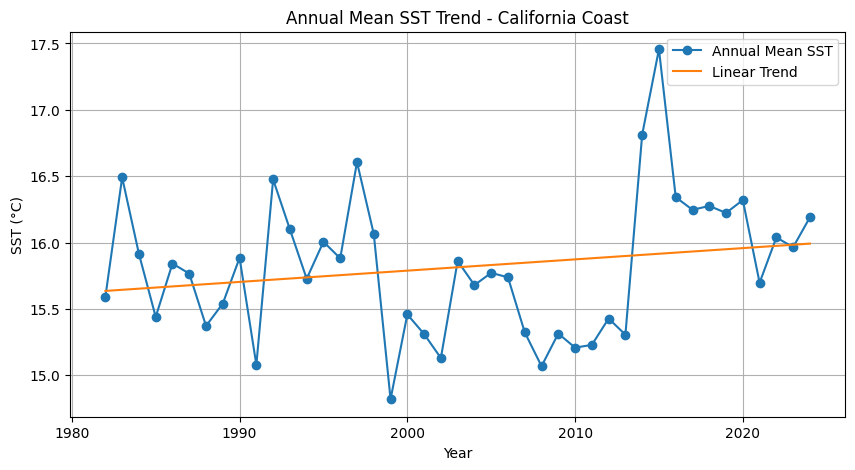

In [14]:
# 绘制趋势线

annual_sst["trend"] = intercept + slope * annual_sst["year"]

plt.figure(figsize=(10, 5))
plt.plot(annual_sst["year"], annual_sst["sst"], marker="o", label="Annual Mean SST")
plt.plot(annual_sst["year"], annual_sst["trend"], label="Linear Trend")
plt.title("Annual Mean SST Trend - California Coast")
plt.xlabel("Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
# 合并 SST 与 ONI（月度）

sst_monthly = sst.set_index("date").resample("MS")["sst"].mean().reset_index()

sst_monthly["year"] = sst_monthly["date"].dt.year
sst_monthly["month"] = sst_monthly["date"].dt.month

merged = sst_monthly.merge(oni[["date", "oni", "enso_phase"]], on="date", how="left")

merged.head()


,date,sst,year,month,oni,enso_phase
0,1982-01-01,14.045085,1982,1,-0.05,Neutral
1,1982-02-01,13.897722,1982,2,0.07,Neutral
2,1982-03-01,13.945116,1982,3,0.19,Neutral
3,1982-04-01,14.433332,1982,4,0.47,Neutral
4,1982-05-01,14.463608,1982,5,0.66,El Niño


In [16]:
# 检查合并结果

print("Merged shape:", merged.shape)
print("Missing ONI values:", merged["oni"].isna().sum())

merged.head(12)


Merged shape: (516, 6)
Missing ONI values: 0


,date,sst,year,month,oni,enso_phase
0,1982-01-01,14.045085,1982,1,-0.05,Neutral
1,1982-02-01,13.897722,1982,2,0.07,Neutral
2,1982-03-01,13.945116,1982,3,0.19,Neutral
3,1982-04-01,14.433332,1982,4,0.47,Neutral
4,1982-05-01,14.463608,1982,5,0.66,El Niño
5,1982-06-01,15.064351,1982,6,0.72,El Niño
6,1982-07-01,16.264917,1982,7,0.79,El Niño
7,1982-08-01,17.032813,1982,8,1.07,El Niño
8,1982-09-01,17.792767,1982,9,1.58,El Niño
9,1982-10-01,17.587773,1982,10,1.97,El Niño


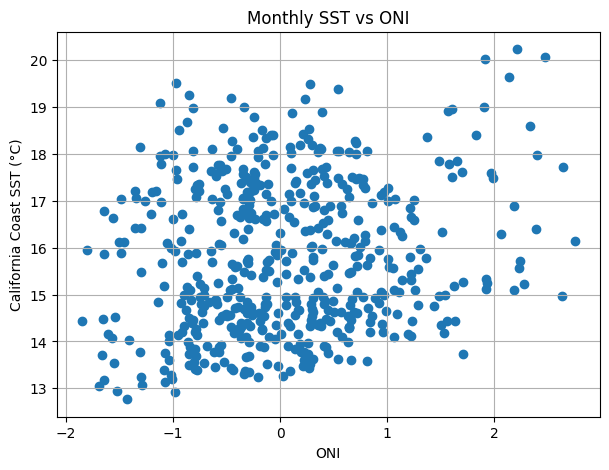

In [17]:
# ONI 与 SST 初步关系图

plt.figure(figsize=(7, 5))
plt.scatter(merged["oni"], merged["sst"])
plt.title("Monthly SST vs ONI")
plt.xlabel("ONI")
plt.ylabel("California Coast SST (°C)")
plt.grid(True)
plt.show()


In [18]:
# 计算 ONI 和 SST 相关性

corr = merged[["sst", "oni"]].corr().loc["sst", "oni"]

print(f"Correlation between monthly California SST and ONI: {corr:.3f}")


Correlation between monthly California SST and ONI: 0.169


In [19]:
# 按 ENSO 阶段比较 SST

enso_summary = (
    merged.groupby("enso_phase")["sst"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

enso_summary


,enso_phase,count,mean,std,min,max
0,El Niño,143,16.074986,1.529562,13.577894,20.230621
1,La Niña,144,15.534840,1.691909,12.769000,19.502594
2,Neutral,229,15.806236,1.587427,13.249933,19.485223


/var/folders/lt/3v655gsn6rlg5jzdqn4nvz500000gn/T/ipykernel_63018/1838283875.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=phase_order)


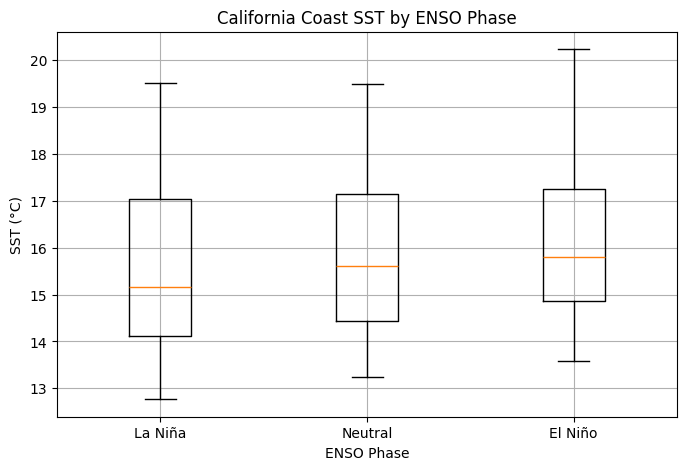

In [20]:
# ENSO 阶段箱线图

phase_order = ["La Niña", "Neutral", "El Niño"]

data_to_plot = [
    merged.loc[merged["enso_phase"] == phase, "sst"].dropna() for phase in phase_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, labels=phase_order)
plt.title("California Coast SST by ENSO Phase")
plt.xlabel("ENSO Phase")
plt.ylabel("SST (°C)")
plt.grid(True)
plt.show()


In [21]:
eda_output_path = PROCESSED_DIR / "monthly_sst_oni_merged.csv"

merged.to_csv(eda_output_path, index=False)

print("Saved:", eda_output_path)


Saved: /Users/sumi/Desktop/project/data/processed/monthly_sst_oni_merged.csv
